In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_excel("/content/REGISTRO_RECLAMOS.xlsx")
df.head(2)

,NRO RECLAMO,MEDIO RECEPCION,FECHA RECEPCION,HORA RECEPCION,LUG. EXPEDIDO,CATEGORIA,MOTIVO_RECLAMO,DETALLE,FECHA RESPUESTA,HORA RESPUESTA,POSICION EMPRESA,MEDIO DE RESPUESTA
0,300,llamada,01 09 2025,8 24 00,LIMA,RE_C1,EXCESIVO CONSUMO,CONSUMIDOR INDICA QUE EXISTE INCREMENTO EN LA...,2025-09-02,16:16:00,NO JUSTIFICADO,llamada
1,301,llamada,01 09 2025,8 28 00,LIMA,RE_C1,NUEVA CONEXIÓN,CONSUMIDORA INDICA QUE SOLICITÓ UN SERVICIO NU...,2025-09-01,11:14:00,JUSTIFICADO,llamada


In [28]:
df.columns.to_list()

['NRO RECLAMO',
 'MEDIO RECEPCION',
 'FECHA RECEPCION',
 'HORA RECEPCION',
 'LUG. EXPEDIDO',
 'CATEGORIA',
 'MOTIVO_RECLAMO',
 'DETALLE',
 'FECHA RESPUESTA',
 'HORA RESPUESTA',
 'POSICION EMPRESA',
 'MEDIO DE RESPUESTA']

In [29]:
df['FECHA RECEPCION'] = pd.to_datetime(df['FECHA RECEPCION'],format = "%d %m %Y")
df['HORA RECEPCION'] = pd.to_timedelta(df['HORA RECEPCION'].str.replace(' ', ':'), errors='coerce')
df.head(2)

,NRO RECLAMO,MEDIO RECEPCION,FECHA RECEPCION,HORA RECEPCION,LUG. EXPEDIDO,CATEGORIA,MOTIVO_RECLAMO,DETALLE,FECHA RESPUESTA,HORA RESPUESTA,POSICION EMPRESA,MEDIO DE RESPUESTA
0,300,llamada,2025-09-01,0 days 08:24:00,LIMA,RE_C1,EXCESIVO CONSUMO,CONSUMIDOR INDICA QUE EXISTE INCREMENTO EN LA...,2025-09-02,16:16:00,NO JUSTIFICADO,llamada
1,301,llamada,2025-09-01,0 days 08:28:00,LIMA,RE_C1,NUEVA CONEXIÓN,CONSUMIDORA INDICA QUE SOLICITÓ UN SERVICIO NU...,2025-09-01,11:14:00,JUSTIFICADO,llamada


In [33]:
# convertir horas a timedelta
df['HORA RECEPCION'] = pd.to_timedelta(df['HORA RECEPCION'].astype(str))
df['HORA RESPUESTA'] = pd.to_timedelta(df['HORA RESPUESTA'].astype(str))

# sumar fecha + hora
df['FECHA HORA RE'] = df['FECHA RECEPCION'] + df['HORA RECEPCION']
df['FECHA HORA RESP'] = df['FECHA RESPUESTA'] + df['HORA RESPUESTA']
df.head(2)

,NRO RECLAMO,MEDIO RECEPCION,FECHA RECEPCION,HORA RECEPCION,LUG. EXPEDIDO,CATEGORIA,MOTIVO_RECLAMO,DETALLE,FECHA RESPUESTA,HORA RESPUESTA,POSICION EMPRESA,MEDIO DE RESPUESTA,FECHA HORA RE,FECHA HORA RESP
0,300,llamada,2025-09-01,0 days 08:24:00,LIMA,RE_C1,EXCESIVO CONSUMO,CONSUMIDOR INDICA QUE EXISTE INCREMENTO EN LA...,2025-09-02,0 days 16:16:00,NO JUSTIFICADO,llamada,2025-09-01 08:24:00,2025-09-02 16:16:00
1,301,llamada,2025-09-01,0 days 08:28:00,LIMA,RE_C1,NUEVA CONEXIÓN,CONSUMIDORA INDICA QUE SOLICITÓ UN SERVICIO NU...,2025-09-01,0 days 11:14:00,JUSTIFICADO,llamada,2025-09-01 08:28:00,2025-09-01 11:14:00


In [34]:
df['TIEMPO']= (df['FECHA HORA RESP'] - df['FECHA HORA RE']).dt.total_seconds()/3600
df.head(2)

,NRO RECLAMO,MEDIO RECEPCION,FECHA RECEPCION,HORA RECEPCION,LUG. EXPEDIDO,CATEGORIA,MOTIVO_RECLAMO,DETALLE,FECHA RESPUESTA,HORA RESPUESTA,POSICION EMPRESA,MEDIO DE RESPUESTA,FECHA HORA RE,FECHA HORA RESP,TIEMPO
0,300,llamada,2025-09-01,0 days 08:24:00,LIMA,RE_C1,EXCESIVO CONSUMO,CONSUMIDOR INDICA QUE EXISTE INCREMENTO EN LA...,2025-09-02,0 days 16:16:00,NO JUSTIFICADO,llamada,2025-09-01 08:24:00,2025-09-02 16:16:00,31.866667
1,301,llamada,2025-09-01,0 days 08:28:00,LIMA,RE_C1,NUEVA CONEXIÓN,CONSUMIDORA INDICA QUE SOLICITÓ UN SERVICIO NU...,2025-09-01,0 days 11:14:00,JUSTIFICADO,llamada,2025-09-01 08:28:00,2025-09-01 11:14:00,2.766667


In [35]:
df.head(1)

,NRO RECLAMO,MEDIO RECEPCION,FECHA RECEPCION,HORA RECEPCION,LUG. EXPEDIDO,CATEGORIA,MOTIVO_RECLAMO,DETALLE,FECHA RESPUESTA,HORA RESPUESTA,POSICION EMPRESA,MEDIO DE RESPUESTA,FECHA HORA RE,FECHA HORA RESP,TIEMPO
0,300,llamada,2025-09-01,0 days 08:24:00,LIMA,RE_C1,EXCESIVO CONSUMO,CONSUMIDOR INDICA QUE EXISTE INCREMENTO EN LA...,2025-09-02,0 days 16:16:00,NO JUSTIFICADO,llamada,2025-09-01 08:24:00,2025-09-02 16:16:00,31.866667


In [49]:
df.describe()

,NRO RECLAMO,FECHA RECEPCION,HORA RECEPCION,FECHA RESPUESTA,HORA RESPUESTA,FECHA HORA RE,FECHA HORA RESP,TIEMPO
count,2534.000000,2534,2534,2534,2534,2534,2534,2534.000000
mean,1568.843725,2025-09-16 18:25:17.284924928,0 days 12:49:55.501183898,2025-09-18 06:19:02.225730048,0 days 14:28:08.263614838,2025-09-17 07:15:12.786108928,2025-09-18 20:47:10.489344768,37.532695
min,300.000000,2025-09-01 00:00:00,0 days 02:20:00,2025-09-01 00:00:00,0 days 00:55:00,2025-09-01 08:24:00,2025-09-01 09:48:00,0.016667
25%,933.250000,2025-09-09 00:00:00,0 days 10:26:15,2025-09-10 00:00:00,0 days 11:40:00,2025-09-09 10:55:00,2025-09-10 15:27:30,4.387500
50%,1567.500000,2025-09-18 00:00:00,0 days 12:36:30,2025-09-19 00:00:00,0 days 14:36:00,2025-09-18 10:19:00,2025-09-19 15:56:00,26.708333
75%,2204.750000,2025-09-25 00:00:00,0 days 15:08:00,2025-09-26 00:00:00,0 days 16:34:45,2025-09-25 12:26:15,2025-09-26 11:59:45,50.895833
max,2840.000000,2025-09-30 00:00:00,0 days 21:12:00,2025-10-15 00:00:00,0 days 23:59:00,2025-09-30 20:09:00,2025-10-15 15:21:00,477.200000
std,733.843055,NaN,0 days 02:55:46.229340471,NaN,0 days 04:08:18.110688156,NaN,NaN,41.864953


In [36]:
df['MOTIVO_RECLAMO'].unique()

array(['EXCESIVO CONSUMO', 'NUEVA CONEXIÓN',
       'OTROS DE SOLICITUDES DE SERVICIO', 'CARGOS INDEBIDOS',
       'FACT.O AVISOS DE COBRANZAS NO RECIBIDO', 'RECONEXIÓN DEMORADA',
       'OTROS DE MALA ATENCIÓN', 'ERROR DE LECTURA ACTUAL',
       'SUSPENSIÓN INDEBIDA DEL SERVICIO', 'MAL ESTADO DEL MEDIDOR',
       'OTROS DE FACTURACION', 'ERROR DE PROMEDIO',
       'ERROR DE LECTURA ANTERIOR', 'CORTE INDEBIDO DEL SERVICIO',
       'SUSPENSIÓN - MAL TRABAJO OPERATIVO', 'CAMBIO DE CATEGORIA',
       'TARIFACIÓN - CATEGORIA ERRADA', 'MALA ATENCION EN OFICINAS',
       'RECONEXIÓN - MAL TRABAJO OPERATIVO', 'TRASLADO -DEMORA',
       'SUSPENSIONES TEMP./DEFINITIVAS - DEMORA',
       'SUSPENSIÓN - RETIRO INDEBIDO DE MEDIDOR',
       'MALA ATENCION EN TERRENO', 'CORTE - MAL TRABAJO OPERATIVO',
       'MALA APLICACIÓN DE RECARGO POR MORA',
       'MALA ATENCION POR TELÉFONO',
       'FACT. O AVISOS DE COBRANZAS FUERA TERMINO',
       'FACTURAS NO RECIBIDA', 'RETIRO INDEBIDO DEL MEDIDOR',
     

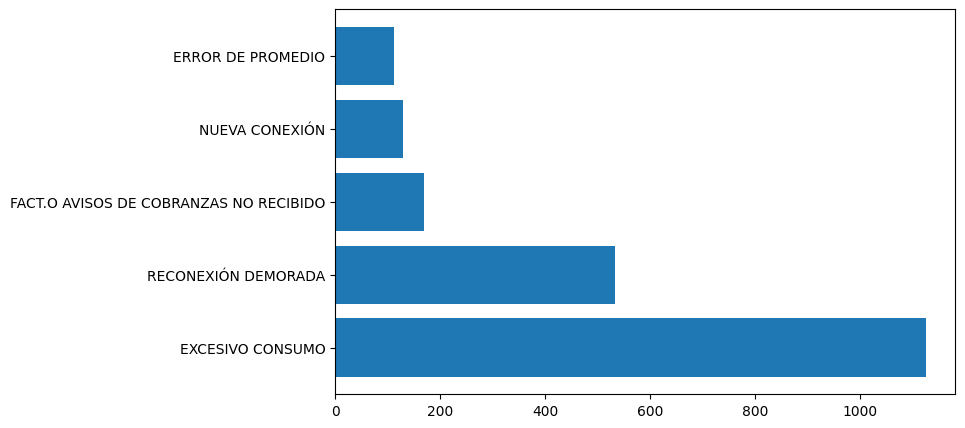

In [39]:
df_motivos = df['MOTIVO_RECLAMO'].value_counts().head(5).reset_index(name='CANTIDAD')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(df_motivos['MOTIVO_RECLAMO'], df_motivos['CANTIDAD'])
plt.show()

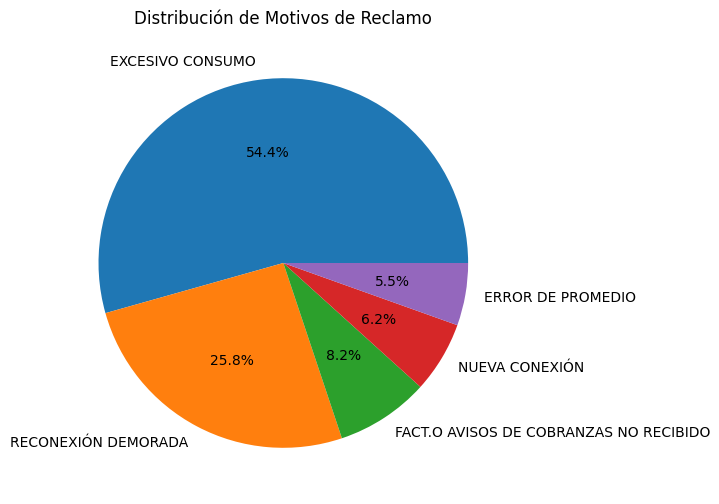

In [40]:
plt.figure(figsize=(6,6))
plt.pie(df_motivos['CANTIDAD'], labels=df_motivos['MOTIVO_RECLAMO'], autopct='%1.1f%%')
plt.title('Distribución de Motivos de Reclamo')
plt.show()

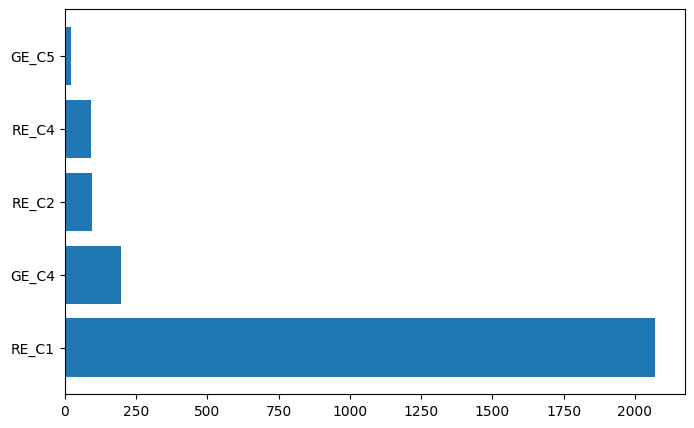

In [47]:
#QUE CATEGORIA RECLAMA MAS
df_categoria = df['CATEGORIA'].value_counts().head().reset_index(name='N RECLAMOS')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(df_categoria['CATEGORIA'], df_categoria['N RECLAMOS'])
plt.show()

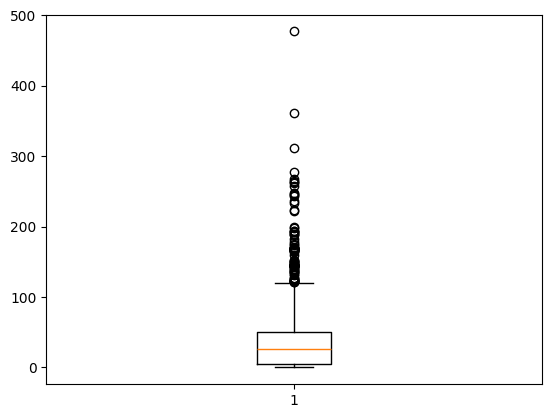

In [48]:
fig, ax = plt.subplots()
ax.boxplot(df['TIEMPO'])
plt.show()

In [51]:
df[df['TIEMPO']>400]

,NRO RECLAMO,MEDIO RECEPCION,FECHA RECEPCION,HORA RECEPCION,LUG. EXPEDIDO,CATEGORIA,MOTIVO_RECLAMO,DETALLE,FECHA RESPUESTA,HORA RESPUESTA,POSICION EMPRESA,MEDIO DE RESPUESTA,FECHA HORA RE,FECHA HORA RESP,TIEMPO
1929,2234,llamada,2025-09-25,0 days 14:55:00,PUNO,RE_C1,CORTE - MAL TRABAJO OPERATIVO,CONSUMIDOR INDICA QUE AL MOMENTO DE REALIZAR E...,2025-10-15,0 days 12:07:00,NO JUSTIFICADO,NaN,2025-09-25 14:55:00,2025-10-15 12:07:00,477.2


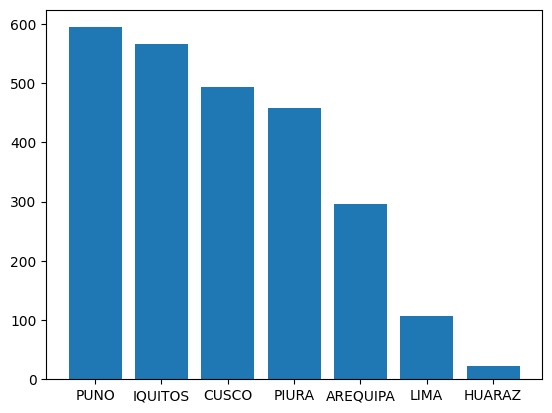

In [54]:
df_lugar = df['LUG. EXPEDIDO'].value_counts().reset_index(name='CANT_RECLAMOS')
fig, ax = plt.subplots()
ax.bar(df_lugar['LUG. EXPEDIDO'], df_lugar['CANT_RECLAMOS'])
plt.show()